# Notebook 03 — Retrieve Better: Bi-Encoder Over-Fetch + Cross-Encoder Rerank

## Tujuan Pembelajaran

Retrieval satu tahap dengan **dense / bi-encoder** bersifat cepat tapi kasar — bagus untuk *recall* (dokumen relevan kemungkinan besar ADA di hasil), tapi lemah untuk *precision* di posisi teratas (urutan belum tentu benar).

**Solusi dua tahap:**
1. **Over-fetch** — bi-encoder mengambil banyak kandidat (mis. 12) dengan biaya murah.
2. **Rerank** — cross-encoder membaca pasangan (query, passage) BERSAMA dan mengurutkan ulang kandidat tersebut dengan akurasi yang jauh lebih tinggi, lalu kita simpan hanya top-3 sebagai konteks generator.

Notebook ini mencakup:
- Membangun FAISS index dengan bi-encoder multilingual
- Over-fetch kandidat
- Reranking dengan `BAAI/bge-reranker-v2-m3`
- Visualisasi rank-change
- Grounded answer generation dengan Qwen2.5-3B-Instruct (4-bit)

In [10]:
!pip install -q "transformers<5" "sentence-transformers>=3.0" faiss-cpu accelerate bitsandbytes

In [11]:
import os, sys
REPO = "navasena-gen-ml-course"
if not os.path.exists(REPO):
    !git clone --depth 1 https://github.com/chmdznr/navasena-gen-ml-course.git
sys.path.append(os.path.abspath(f"{REPO}/05_rag"))
from tools.rag_utils import rank_change_table

## Bi-Encoder vs Cross-Encoder

| Aspek | Bi-Encoder | Cross-Encoder |
|-------|-----------|---------------|
| **Cara kerja** | Embed query & dokumen **TERPISAH** | Proses pasangan (query, passage) **BERSAMA** |
| **Kecepatan** | Cepat — vektor bisa pra-hitung offline | Lambat — setiap pasangan butuh satu forward pass |
| **Akurasi ranking** | Kasar — tak melihat interaksi kata per kata | Tajam — memodelkan interaksi query↔passage secara penuh |
| **Skalabilitas** | Jutaan dokumen (ANN search) | Puluhan–ratusan kandidat |

**Strategi dua tahap:**
- **Tahap 1 (bi-encoder)** — saring dari jutaan → puluhan kandidat (over-fetch)
- **Tahap 2 (cross-encoder)** — urutkan ulang puluhan kandidat → simpan top-K

Bi-encoder menjamin *recall*; cross-encoder menjamin *precision* di posisi teratas.

In [12]:
# Korpus mirip chunk RAG nyata: potongan buku panduan karyawan, 2-3 kalimat.
# JEBAKAN: passage jawaban memakai sinonim ("libur berbayar"), sedangkan ada
# distraktor yang memuat frasa query secara VERBATIM ("pengajuan cuti tahunan")
# tapi hanya membahas PROSES, bukan jumlah harinya. Bi-encoder cenderung
# tertipu kemiripan kata; cross-encoder membaca pasangan (query, passage)
# sehingga bisa mengenali passage mana yang benar-benar menjawab.
corpus = [
    "Setiap pegawai tetap memperoleh jatah dua belas hari libur berbayar dalam satu tahun, terpisah dari hari libur nasional. Sisa jatah yang tidak digunakan akan hangus pada akhir periode dan tidak dapat diuangkan.",
    "Pengajuan cuti tahunan dilakukan melalui portal karyawan dan wajib mendapat persetujuan atasan langsung paling lambat tiga hari sebelum tanggal yang diinginkan.",
    "Cuti sakit dapat diambil hingga sepuluh hari setiap tahun dan harus disertai surat keterangan dari dokter bila lebih dari dua hari berturut-turut.",
    "Karyawan baru menjalani masa orientasi selama tiga hari kerja pertama, mencakup pengenalan budaya perusahaan dan pelatihan keselamatan.",
    "Cuti melahirkan diberikan selama tiga bulan penuh sesuai ketentuan ketenagakerjaan yang berlaku di Indonesia.",
    "Jam kerja standar adalah pukul 09.00 hingga 17.00 dari Senin sampai Jumat, dengan satu jam istirahat untuk makan siang.",
    "Karyawan dapat bekerja dari rumah maksimal dua hari dalam seminggu setelah mendapat persetujuan dari manajer tim.",
    "Gaji dibayarkan pada tanggal 25 setiap bulan melalui transfer bank ke rekening masing-masing pegawai.",
    "Perusahaan menyediakan asuransi kesehatan yang mencakup rawat inap dan rawat jalan bagi pegawai beserta satu anggota keluarga.",
    "Lembur pada hari libur dihitung dua kali lipat dari tarif normal dan harus dicatat dalam sistem absensi sebelum dikerjakan.",
    "Pelanggaran kode etik dapat berujung pada surat peringatan hingga pemutusan hubungan kerja sesuai tingkat keparahannya.",
    "Penggantian biaya perjalanan dinas diajukan paling lambat tujuh hari setelah perjalanan dengan melampirkan bukti pembayaran yang sah.",
]
print(f"{len(corpus)} passage (chunk buku panduan) dalam korpus")

12 passage (chunk buku panduan) dalam korpus


In [13]:
import faiss, numpy as np
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
corpus_vecs = embedder.encode(corpus, convert_to_numpy=True).astype("float32")
dim = corpus_vecs.shape[1]
index = faiss.IndexFlatL2(dim)   # cosine/IndexFlatIP diperkenalkan di nb05; L2 cukup untuk tahap penyaringan
index.add(corpus_vecs)
print("dim:", dim, "| index size:", index.ntotal)

dim: 384 | index size: 12


## Tahap 1: Over-Fetch dengan Bi-Encoder

Ambil lebih banyak kandidat dari yang dibutuhkan (K=12) supaya jawaban benar kemungkinan besar **ADA** di kandidat walau belum di posisi #1.

Bi-encoder murah karena:
- Vektor dokumen sudah pra-hitung di index
- Hanya query yang di-embed saat runtime
- FAISS menggunakan ANN (approximate nearest neighbor) yang sangat cepat

Jadi over-fetch dengan K=12 hampir tidak lebih mahal dari K=3.

Catatan: FAISS mengembalikan *jarak* L2 (makin kecil = makin mirip). Kita balik tandanya (× -1) supaya skor lebih tinggi berarti lebih mirip — konsisten dengan konvensi skor relevansi. Untuk vektor ternormalisasi, jarak L2 dan cosine setara secara urutan.

Di notebook ini korpusnya kecil (12 passage) sehingga kita ambil semuanya (K=12); pada sistem nyata K jauh lebih kecil dari total dokumen (mis. ambil 50 teratas dari jutaan). Kita sengaja over-fetch banyak supaya passage jawaban yang mungkin di-rank rendah oleh bi-encoder tetap masuk daftar kandidat untuk di-rerank — justru itulah alasan kita perlu tahap rerank.

In [14]:
query = "Berapa hari cuti tahunan yang didapat seorang pegawai tetap?"
K = 12
qv = embedder.encode([query], convert_to_numpy=True).astype("float32")
dist, idx = index.search(qv, K)
candidate_ids = idx[0].tolist()
bi_scores = [float(-d) for d in dist[0]]   # negate L2 distance so higher = lebih mirip
print(f"Query: {query}\n\nTahap 1 — bi-encoder over-fetch (top {K}):")
for rank, cid in enumerate(candidate_ids, 1):
    print(f"  bi#{rank:2d} | doc {cid:2d} | {corpus[cid][:72]}")

Query: Berapa hari cuti tahunan yang didapat seorang pegawai tetap?

Tahap 1 — bi-encoder over-fetch (top 12):
  bi# 1 | doc  0 | Setiap pegawai tetap memperoleh jatah dua belas hari libur berbayar dala
  bi# 2 | doc  1 | Pengajuan cuti tahunan dilakukan melalui portal karyawan dan wajib menda
  bi# 3 | doc  6 | Karyawan dapat bekerja dari rumah maksimal dua hari dalam seminggu setel
  bi# 4 | doc  9 | Lembur pada hari libur dihitung dua kali lipat dari tarif normal dan har
  bi# 5 | doc  5 | Jam kerja standar adalah pukul 09.00 hingga 17.00 dari Senin sampai Juma
  bi# 6 | doc  2 | Cuti sakit dapat diambil hingga sepuluh hari setiap tahun dan harus dise
  bi# 7 | doc  3 | Karyawan baru menjalani masa orientasi selama tiga hari kerja pertama, m
  bi# 8 | doc  7 | Gaji dibayarkan pada tanggal 25 setiap bulan melalui transfer bank ke re
  bi# 9 | doc 10 | Pelanggaran kode etik dapat berujung pada surat peringatan hingga pemutu
  bi#10 | doc 11 | Penggantian biaya perjalanan dinas diajuka

## Tahap 2: Rerank dengan Cross-Encoder

Cross-encoder membaca pasangan **(query, passage) BERSAMA** dalam satu forward pass model, sehingga bisa memodelkan interaksi semantik yang detail — misalnya frasa "cuti tahunan" pada query berinteraksi berbeda dengan "dua belas hari libur berbayar" (jawaban sebenarnya) vs "pengajuan cuti tahunan lewat portal" (jebakan verbatim yang hanya menjelaskan proses).

Hasilnya adalah skor relevansi yang jauh lebih tajam. Kita simpan **top-3** sebagai konteks untuk generator.

Model: `BAAI/bge-reranker-v2-m3` — cross-encoder multilingual, non-gated, muat di T4.

In [15]:
from sentence_transformers import CrossEncoder
# Model ~2.3 GB (fp32) — diunduh sekali ke cache Colab, butuh ~2-4 menit pada koneksi standar (wajar kalau lambat, bukan hang).
# bge-reranker-v2-m3: cross-encoder multilingual, non-gated, muat di T4.
reranker = CrossEncoder("BAAI/bge-reranker-v2-m3", max_length=512)
pairs = [(query, corpus[cid]) for cid in candidate_ids]
rerank_scores = reranker.predict(pairs).tolist()
rows = rank_change_table(candidate_ids, bi_scores, rerank_scores, top_k=3)
top3 = [r for r in rows if r["kept"]]
print("Tahap 2 — setelah cross-encoder rerank (top 3 disimpan):")
for r in top3:
    print(f"  rerank#{r['rerank_rank']} | doc {r['doc_id']} (asalnya bi#{r['bi_rank']}, delta {r['delta']:+d}) | {corpus[r['doc_id']][:60]}")

Tahap 2 — setelah cross-encoder rerank (top 3 disimpan):
  rerank#1 | doc 0 (asalnya bi#1, delta +0) | Setiap pegawai tetap memperoleh jatah dua belas hari libur b
  rerank#2 | doc 1 (asalnya bi#2, delta +0) | Pengajuan cuti tahunan dilakukan melalui portal karyawan dan
  rerank#3 | doc 2 (asalnya bi#6, delta +3) | Cuti sakit dapat diambil hingga sepuluh hari setiap tahun da


## Membaca Rank-Change

Kolom **delta** = bi_rank − rerank_rank:
- **delta > 0** (hijau) — dokumen **NAIK** setelah rerank: cross-encoder menilainya lebih relevan dari perkiraan bi-encoder
- **delta < 0** (merah) — dokumen **TURUN**: bi-encoder terlalu optimis karena kesamaan leksikal saja
- **delta = 0** (abu) — urutan tidak berubah

Perlu diperhatikan: skor bi-encoder (negatif L2) dan skor cross-encoder berada di **skala yang berbeda** — keduanya tidak bisa dibandingkan secara langsung. Grafik kiri (scatter) hanya menunjukkan bahwa kedua skor tidak berkorelasi penuh; yang benar-benar menunjukkan *reordering* adalah **grafik kanan (delta bar chart)**.

Harapannya passage jawaban (doc 0, "dua belas hari libur berbayar") **DIPROMOSIKAN** ke atas, sementara jebakan verbatim "Pengajuan cuti tahunan ..." (doc 1, hanya menjelaskan proses) dan "Cuti sakit ... sepuluh hari" (doc 2, jenis cuti berbeda) **TURUN**. Inilah bukti bahwa cross-encoder memahami *makna* — kata "cuti tahunan" pada query berinteraksi dengan "dua belas hari libur berbayar" (jawaban sebenarnya) vs "pengajuan cuti tahunan lewat portal" (hanya menjelaskan proses).

Kalaupun bi-encoder sudah menaruh doc 0 di posisi #1, delta-nya 0 — itu pun informasi penting. Yang paling penting diperhatikan: apakah doc 1/doc 2 **TURUN** — itu bukti cross-encoder memilah makna, bukan sekadar kemiripan kata.

doc  bi  rr  delta  kept  teks
  0   1   1     +0  True  Setiap pegawai tetap memperoleh jatah dua belas 
  1   2   2     +0  True  Pengajuan cuti tahunan dilakukan melalui portal 
  2   6   3     +3  True  Cuti sakit dapat diambil hingga sepuluh hari set
  4  11   4     +7 False  Cuti melahirkan diberikan selama tiga bulan penu
  7   8   5     +3 False  Gaji dibayarkan pada tanggal 25 setiap bulan mel
  6   3   6     -3 False  Karyawan dapat bekerja dari rumah maksimal dua h
  3   7   7     +0 False  Karyawan baru menjalani masa orientasi selama ti
 11  10   8     +2 False  Penggantian biaya perjalanan dinas diajukan pali
  9   4   9     -5 False  Lembur pada hari libur dihitung dua kali lipat d
  5   5  10     -5 False  Jam kerja standar adalah pukul 09.00 hingga 17.0
  8  12  11     +1 False  Perusahaan menyediakan asuransi kesehatan yang m
 10   9  12     -3 False  Pelanggaran kode etik dapat berujung pada surat 


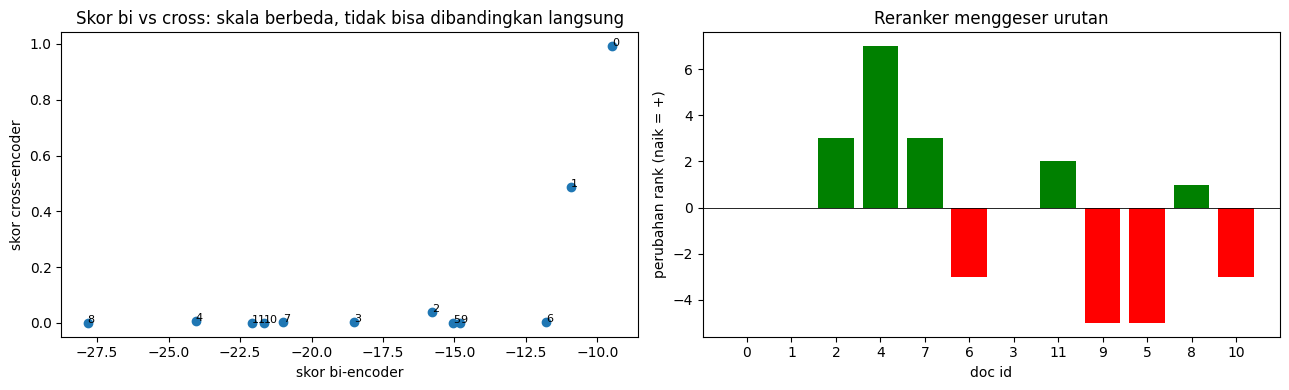

In [16]:
import matplotlib.pyplot as plt
print(f"{'doc':>3} {'bi':>3} {'rr':>3} {'delta':>6} {'kept':>5}  teks")
for r in rows:
    print(f"{r['doc_id']:>3} {r['bi_rank']:>3} {r['rerank_rank']:>3} {r['delta']:>+6} {str(r['kept']):>5}  {corpus[r['doc_id']][:48]}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter([r['bi_score'] for r in rows], [r['rerank_score'] for r in rows])
for r in rows:
    ax[0].annotate(str(r['doc_id']), (r['bi_score'], r['rerank_score']), fontsize=8)
ax[0].set_xlabel('skor bi-encoder'); ax[0].set_ylabel('skor cross-encoder')
ax[0].set_title('Skor bi vs cross: skala berbeda, tidak bisa dibandingkan langsung')

docs = [str(r['doc_id']) for r in rows]; deltas = [r['delta'] for r in rows]
ax[1].bar(docs, deltas, color=['green' if d > 0 else ('red' if d < 0 else 'grey') for d in deltas])
ax[1].axhline(0, color='black', linewidth=0.6)
ax[1].set_xlabel('doc id'); ax[1].set_ylabel('perubahan rank (naik = +)')
ax[1].set_title('Reranker menggeser urutan')
plt.tight_layout(); plt.show()

## Biaya: Mengapa Cross-Encoder Tidak Dipakai untuk Seluruh Korpus?

Cross-encoder **mahal** karena setiap pasangan (query, passage) membutuhkan satu forward pass model penuh — tidak ada vektor yang bisa pra-hitung atau diindeks.

- Korpus 1 juta dokumen × 1 forward pass/pasangan = **1 juta inference** per query
- Dengan bi-encoder FAISS: index search ~1ms; hanya **K forward pass** untuk reranker

Itulah sebabnya arsitektur dua tahap ini menjadi standar industri: bi-encoder menjaga agar set kandidat tetap kecil, sehingga cross-encoder tetap layak secara komputasi.

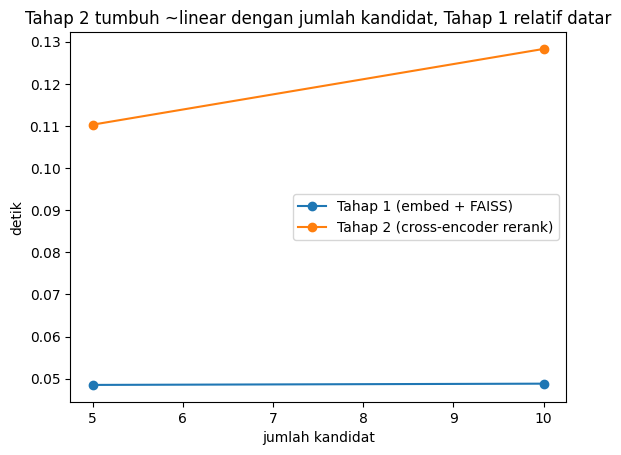

In [17]:
import time
sizes = [s for s in [5, 10, 20, 40] if s <= len(corpus)]
d_all, i_all = index.search(qv, min(max(sizes), len(corpus)))
pool = i_all[0].tolist()
t1, t2 = [], []
for n in sizes:
    s0 = time.perf_counter(); _ = embedder.encode([query], convert_to_numpy=True); _ = index.search(qv, n); t1.append(time.perf_counter() - s0)
    pr = [(query, corpus[c]) for c in pool[:n]]
    s0 = time.perf_counter(); _ = reranker.predict(pr); t2.append(time.perf_counter() - s0)
plt.plot(sizes, t1, marker='o', label='Tahap 1 (embed + FAISS)')
plt.plot(sizes, t2, marker='o', label='Tahap 2 (cross-encoder rerank)')
plt.xlabel('jumlah kandidat'); plt.ylabel('detik'); plt.legend()
# Catatan: angka detik berbeda di CPU vs GPU; yang penting TRENNYA — Tahap 2 naik dengan jumlah kandidat.
plt.title('Tahap 2 tumbuh ~linear dengan jumlah kandidat, Tahap 1 relatif datar'); plt.show()

## Grounded Answer Generation

Sekarang kita tutup loop RAG: 3 passage ter-rerank dikirim sebagai **konteks** ke model generator.

Generator diminta untuk:
1. Menjawab **HANYA** berdasarkan konteks yang diberikan (grounded)
2. Menyertakan **sitasi** `(doc N)` sehingga jawaban bisa diverifikasi

Model: `Qwen/Qwen2.5-3B-Instruct` dengan 4-bit quantization (NF4) — muat di T4 GPU Colab.

In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                         bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)
model_name = "Qwen/Qwen2.5-3B-Instruct"
tok = AutoTokenizer.from_pretrained(model_name)
gen = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb, device_map="auto")

context = "\n".join(f"[doc {r['doc_id']}] {corpus[r['doc_id']]}" for r in top3)
messages = [
    {"role": "system", "content": "Jawab HANYA berdasarkan konteks. Sertakan id dokumen sebagai sitasi, mis. (doc 0)."},
    {"role": "user", "content": f"Konteks:\n{context}\n\nPertanyaan: {query}"},
]
prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tok(prompt, return_tensors="pt").to(gen.device)
out = gen.generate(**inputs, max_new_tokens=160, do_sample=False)
print(tok.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip())

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Dapat dilihat dari dokumen [doc 0], setiap pegawai tetap memperoleh jatah cuti tahunan sebesar dua belas hari.


## Ringkasan & Jembatan ke Notebook 04

**Yang sudah kita pelajari di nb03:**

| Tahap | Komponen | Peran |
|-------|----------|-------|
| 1 | Bi-encoder + FAISS | Over-fetch cepat → jamin *recall* |
| 2 | Cross-encoder (bge-reranker-v2-m3) | Rerank → tingkatkan *precision* posisi teratas |
| 3 | Generator (Qwen2.5-3B-Instruct) | Grounded answer dengan sitasi |

**Reranking meningkatkan *context precision*** — passage yang benar-benar menjawab pertanyaan naik ke posisi teratas, bukan hanya yang mengandung kata yang sama. Contoh konkret: jebakan verbatim "pengajuan cuti tahunan" (hanya proses) TURUN, sementara passage jawaban "dua belas hari libur berbayar" (sinonim dari cuti tahunan) NAIK ke teratas.

**Di Notebook 04 (Measure / RAGAS)**, kita akan **mengukur efek ini secara kuantitatif**: dengan query yang sama, bandingkan pipeline tanpa rerank vs dengan rerank menggunakan metrik seperti `context_precision`, `context_recall`, dan `answer_relevancy`. Angka akan membuktikan apa yang baru saja kita lihat secara visual.